# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful **starting points** for the extension include:_

* **Stereo view synthesis:** Start from a **dense disparity map** (e.g. the motorcycle stereo pair in Part 2) and aim to **draw the scene again** as if a **second, shifted camera** had taken the picture- not just a false-color disparity plot.

* **Metric depth:** Turn disparities into **metric depth** with $\text{depth} = \frac{B \cdot f}{\text{disparity}}$ using a plausible **baseline** and **focal length**, and stabilize the denominator when disparity is tiny or noisy.

* **Calibration & lifting:** Use the camera **intrinsics** ($3 \times 3$ matrix $K$) together with disparity and baseline to **lift pixels from the image into 3D** in the original camera’s coordinate frame.

* **Virtual camera motion:** Describe how the new camera sits relative to the first with a **rigid motion**—a **rotation** and **translation**—and **move every 3D point** into that new camera’s frame before drawing.

* **Rendering:** **Project** those 3D points back onto a **fresh image grid** with intrinsics suited to the new view, producing the **rerendered photograph** (including how you handle resolution, bounds, and empty pixels).

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: David Lowe, “Distinctive Image Features from Scale-Invariant Keypoints” (2004)- https://link.springer.com/article/10.1023/B:VISI.0000029664.99615.94
This paper introduces SIFT and the ratio test used in feature matching. It shows how comparing nearest neighbors helps filter incorrect matches. This directly supports my experiment on how the ratio threshold affects matching results.
* Source 2: David Lowe, “Automatic Panoramic Image Stitching using Invariant Features" (2006)- https://link.springer.com/article/10.1007/s11263-006-0002-3
This paper demonstrates how Lowe’s ratio test is used to filter matches in panorama stitching. It shows that removing ambiguous matches is essential for accurate alignment. This inspired my exploration of how changing the ratio threshold affects matching performance.
* Source 3: OpenCV Feature Matching Tutorial-https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
This tutorial shows how feature matching is implemented in practice using nearest neighbors and Lowe’s ratio test. It explains how to use two nearest matches (k=2) and filter them based on a threshold. This connects directly to how the ratio test is applied in real computer vision systems.

* Source 4: Brown, Szeliski, and Winder, “Multi-Image Matching using Multi-Scale Oriented Patches” (2005)
This paper presents an alternative feature descriptor (MOPS) and discusses feature matching performance across images. It highlights the importance of reliable matching criteria and compares different approaches to filtering matches. This provides context for why techniques like the ratio test are necessary for reducing incorrect correspondences.

* Source 5: Roboflow Blog – “What is Feature Matching?” – https://blog.roboflow.com/what-is-feature-matching/
This tutorial provides an intuitive explanation of feature matching and why filtering is needed. It explains that if the closest and second-closest matches are too similar, the match is likely unreliable, which is exactly what the ratio test captures. It also discusses how the threshold controls the trade-off between match quality and quantity.


## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You are not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from skimage import filters
from skimage.feature import corner_peaks
from scipy.ndimage import convolve
from scipy.spatial.distance import cdist

In [2]:
def harris_corners(img, window_size=3, k=0.04):
    """
    Compute Harris corner response map. Follow the math equation
    R=Det(M)-k(Trace(M)^2).

    Hint:
        You may use the function scipy.ndimage.filters.convolve,
        which is already imported above. If you use convolve(), remember to
        specify zero-padding to match our equations, for example:

            out_image = convolve(in_image, kernel, mode='constant', cval=0)

        You can also use for nested loops compute M and the subsequent Harris
        corner response for each output pixel, intead of using convolve().
        Your implementation of conv_fast or conv_nested in HW1 may be a
        useful reference!

    Args:
        img: Grayscale image of shape (H, W)
        window_size: size of the window function
        k: sensitivity parameter

    Returns:
        response: Harris response image of shape (H, W)
    """

    H, W = img.shape
    window = np.ones((window_size, window_size))

    response = np.zeros((H, W))

    # 1. Compute x and y derivatives (I_x, I_y) of an image
    dx = filters.sobel_v(img)
    dy = filters.sobel_h(img)

    ### YOUR CODE HERE
    Ixx = dx * dx
    Iyy = dy * dy
    Ixy = dx * dy

    Sxx = convolve(Ixx, window, mode='constant', cval=0)
    Syy = convolve(Iyy, window, mode='constant', cval=0)
    Sxy = convolve(Ixy, window, mode='constant', cval=0)

    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy

    response = det_M - k * (trace_M ** 2)
    ### END YOUR CODE

    return response

def simple_descriptor(patch):
    """
    Describe the patch by normalizing the image values into a standard
    normal distribution (having mean of 0 and standard deviation of 1)
    and then flattening into a 1D array.

    The normalization will make the descriptor more robust to change
    in lighting condition.

    Hint:
        In this case of normalization, if a denominator is zero, divide by 1 instead.

    Args:
        patch: grayscale image patch of shape (H, W)

    Returns:
        feature: 1D array of shape (H * W)
    """

    feature = []

    ### YOUR CODE HERE
    mean = np.mean(patch)
    std = np.std(patch)
    if std == 0:
        std = 1
    feature = ((patch - mean) / std).flatten()
    ### END YOUR CODE

    return feature

def match_descriptors(desc1, desc2, threshold=0.5):
    """
    Match the feature descriptors by finding distances between them. A match is formed
    when the distance to the closest vector is much smaller than the distance to the
    second-closest, that is, the ratio of the distances should be STRICTLY SMALLER
    than the threshold (NOT equal to). Return the matches as pairs of vector indices.

    Hint:
        The Numpy functions np.sort, np.argmin, np.asarray might be useful

        The Scipy function cdist calculates Euclidean distance between all
        pairs of inputs
    Args:
        desc1: an array of shape (M, P) holding descriptors of size P about M keypoints
        desc2: an array of shape (N, P) holding descriptors of size P about N keypoints

    Returns:
        matches: an array of shape (Q, 2) where each row holds the indices of one pair
        of matching descriptors
    """

    matches = []

    M = desc1.shape[0]
    dists = cdist(desc1, desc2)

    ### YOUR CODE HERE
    for i in range(M):
        row = dists[i]
        sorted_indices = np.argsort(row)
        closest_idx = sorted_indices[0]
        second_closest_idx = sorted_indices[1]

        if row[closest_idx] / row[second_closest_idx] < threshold:
            matches.append([i, closest_idx])

    matches = np.asarray(matches)
    ### END YOUR CODE

    return matches


In [3]:
def describe_keypoints(image, keypoints, desc_func, patch_size=5):
    desc = []

    for y, x in keypoints:
        patch = image[y - patch_size//2 : y + patch_size//2 + 1,
                      x - patch_size//2 : x + patch_size//2 + 1]

        if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
            desc.append(desc_func(patch))

    return np.array(desc)
def plot_matches(img1, img2, kpts1, kpts2, matches):
    h1, w1 = img1.shape
    h2, w2 = img2.shape

    canvas = np.zeros((max(h1, h2), w1 + w2))
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1 + w2] = img2

    plt.imshow(canvas, cmap='gray')

    for i, j in matches:
        y1, x1 = kpts1[i]
        y2, x2 = kpts2[j]

        plt.plot([x1, x2 + w1], [y1, y2], 'r-', linewidth=0.5)

    plt.axis('off')

In [10]:

def run_matching_experiment(img1, img2, thresholds=[0.5, 0.7, 0.9]):

    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)

    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)

    desc1 = describe_keypoints(img1, kpts1, desc_func=simple_descriptor, patch_size=5)
    desc2 = describe_keypoints(img2, kpts2, desc_func=simple_descriptor, patch_size=5)

    results = []

    for t in thresholds:
        matches = match_descriptors(desc1, desc2, threshold=t)
        results.append((t, matches, kpts1, kpts2))

    return img1, img2, results


def visualize_results(img1, img2, results, name="set"):

    plt.figure(figsize=(15, 5))

    for i, (t, matches, kpts1, kpts2) in enumerate(results):
        plt.subplot(1, 3, i+1)
        plot_matches(img1, img2, kpts1, kpts2, matches)
        plt.title(f"{name} | t={t} | matches={len(matches)}")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()


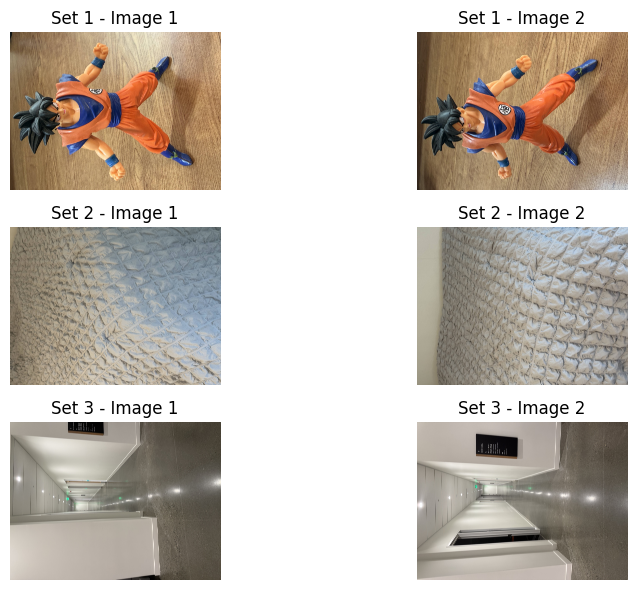

In [12]:
def show_original_images(image_sets):
    plt.figure(figsize=(10, 6))

    for i, (p1, p2) in enumerate(image_sets):
        img1 = io.imread(p1)
        img2 = io.imread(p2)

        plt.subplot(len(image_sets), 2, 2*i + 1)
        plt.imshow(img1)
        plt.title(f"Set {i+1} - Image 1")
        plt.axis('off')

        plt.subplot(len(image_sets), 2, 2*i + 2)
        plt.imshow(img2)
        plt.title(f"Set {i+1} - Image 2")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
show_original_images(image_sets)

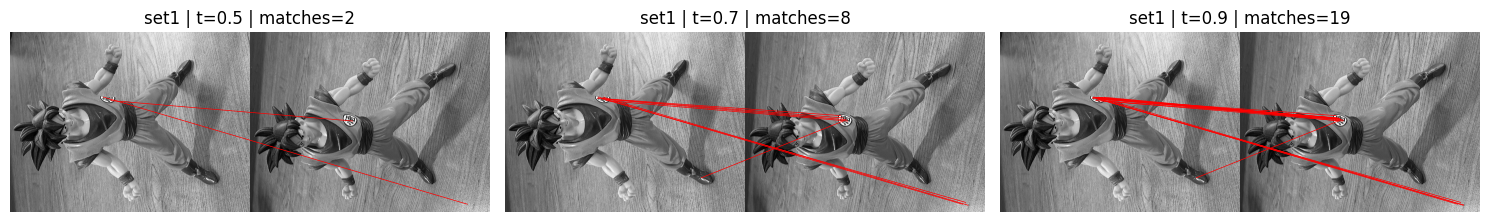

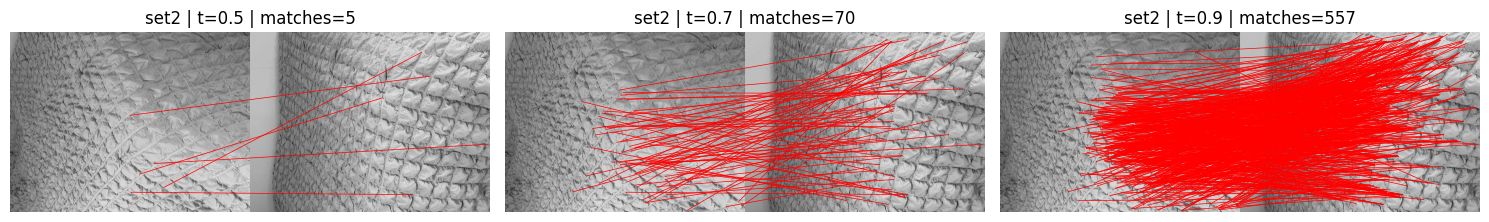

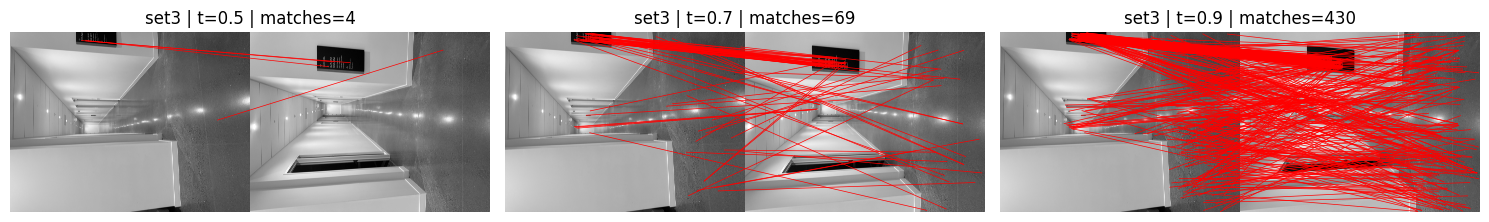

In [9]:


image_sets = [
    ("goku1.jpg", "goku2.jpg"),
    ("blanket1.jpg", "blanket2.jpg"),
    ("hallway1.jpg", "hallway2.jpg"),
]


for i, (p1, p2) in enumerate(image_sets):
    img1 = io.imread(p1)
    img2 = io.imread(p2)

    img1, img2, results = run_matching_experiment(img1, img2)

    visualize_results(img1, img2, results, name=f"set{i+1}")

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_